In [1]:
from dotenv import load_dotenv
load_dotenv("./../.env")

True

In [2]:
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_chroma import Chroma

CHROMA_DIR = "chroma_financial_db_lite"
COLLECTION_NAME = "financial_docs"
EMBEDDING_MODEL = "nomic-embed-text"
BASE_URL = "http://localhost:11434"
LLM_MODEL = "qwen3.5:397b-cloud" 

In [3]:
embeddings= OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=BASE_URL, num_ctx=8192)

vector_store = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR
)

vector_store._collection.count()

213

In [4]:
llm = ChatOllama(model = LLM_MODEL, base_url=BASE_URL)
llm.invoke("Hi there!")

AIMessage(content="Hi there! How's your day going? Is there anything I can help you with?", additional_kwargs={}, response_metadata={'model': 'qwen3.5:397b-cloud', 'created_at': '2026-03-11T13:15:30.321589156Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13544666740, 'load_duration': None, 'prompt_eval_count': 13, 'prompt_eval_duration': None, 'eval_count': 417, 'eval_duration': None, 'logprobs': None, 'model_name': 'qwen3.5:397b-cloud', 'model_provider': 'ollama'}, id='lc_run--019cdd09-89fb-7281-8912-7fe3ca143fbb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 417, 'total_tokens': 430})

In [5]:
from utils import page_rerank, page_retrieval


In [9]:
page_retrieval.extract_filters("what is amazon's revenue in 2023?")

{}

In [8]:
page_rerank.generate_ranking_keywords("what is amazon's revenue in 2023?")

['revenue',
 'net revenue',
 'consolidated statements of operations',
 'operating income',
 'net income']

In [32]:
import os
from langchain_community.tools import tool
@tool
def page_retrieval_rerank(query:str):
    """
    Retrieve relevant financial documents from ChromaDB.
    Extracts filters from query and retrieves matching documents.

    Args:
        query: The search query (e.g., "What was Amazon's revenue in Q2 2025?")
        k: Number of documents to retrieve. generally prefer 5 docs

    Returns:
        Retrieved documents with metadata as formatted string
    """
    print(f"\n[TOOL] retrieve_docs called")
    print(f"[QUERY] {query}")

    k = 5

    # 必要关键词字典
    #keywords = page_retrieval.extract_filters(query)
    keywords = {'company_name': 'amazon', 'fiscal_year': 2023}
    print(f'keywords: {keywords}')
    # 参考关键词字典
    #references = page_rerank.generate_ranking_keywords(query)a
    references = ['revenue','net revenue','consolidated statements of operations','operating income','net income']
    print(f'references: {references}')
    # 使用关键词搜索数据库内容
    raw_result = page_retrieval.search_docs(query=query, 
                                            vector_store=vector_store, 
                                            filters=keywords, 
                                            ranking_keywords=references, k=5*k)
    # 返回排序后的页面内容
    ranked_result = page_rerank.rank_documents_by_keywords(docs=raw_result, keywords=references, k=k)

    print(f"[RETRIEVED] {len(ranked_result)} documents")

    # format extracted docs or chunks
    if len(ranked_result)==0:
        return f"No ducuments found for the query: '{query}'. Try rephrasing query or use different filter."
    
    # final format
    # --- Document {i} ---
    retrieved_text = []
    for i, doc in enumerate(ranked_result, 1):
        doc_text = [f"--- Document {i} ---"]

        # add all metadata
        for key, value in doc.metadata.items():
            doc_text.append(f"{key}: {value}")

        # add content
        doc_text.append(f"\nContent:\n{doc.page_content}")

        text = "\n".join(doc_text)
        retrieved_text.append(text)

    retrieved_text = "\n".join(retrieved_text)

    os.makedirs("debug_logs", exist_ok=True)
    with open("debug_logs/retrieved_reranked_docs.md", "w", encoding='utf-8') as f:
        f.write(retrieved_text)

    return retrieved_text
    


In [19]:
from typing_extensions import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [20]:
import operator
class AgentState(TypedDict):
    messages:Annotated[list, operator.add]

In [33]:
def AgentNode(state:AgentState):
    tool_llm = llm.bind_tools([page_retrieval_rerank])
    system_prompt = SystemMessage("""You are a financial document analysis assistant with access to a document retrieval tool.

                CRITICAL RULES:
                1. ALWAYS use the retrieve_docs tool first - NEVER answer from memory
                2. You MUST call the tool before providing any financial information
                3. Answer ONLY based on the retrieved documents
                4. If documents don't contain the answer, clearly state that

                WORKFLOW FOR SIMPLE QUESTIONS:
                Step 1: Call retrieve_docs tool with the user's question
                Step 2: Wait for the tool results
                Step 3: Analyze the retrieved documents
                Step 4: Provide answer with citations (company, year, quarter, page)

                WORKFLOW FOR COMPLEX/COMPARISON QUESTIONS:
                Step 1: Break down the question into sub-questions
                Example: "Compare Amazon and Google revenue" -> 
                - Sub-question 1: "Amazon revenue"
                - Sub-question 2: "Google revenue"

                Step 2: Call retrieve_docs for EACH sub-question separately
                - First call for Amazon
                - Wait for results
                - Second call for Google
                - Wait for results

                Step 3: Analyze all retrieved documents

                Step 4: Present comparison in TABLE format:
                | Metric | Company A | Company B |
                |--------|-----------|-----------|
                | Revenue | $X | $Y |

                ANSWER FORMATTING (Use Markdown):
                - Use **headings** (##, ###) for sections
                - Use paragraphs for detailed findings and reasonings
                - Use **bullet points** for lists
                - Use **tables** for comparisons and structured data
                - Use **bold** for emphasis on key metrics
                - Cite sources: (Company: X, Year: Y, Quarter: Z, Page: N)

                EXAMPLES:

                Example 1 - Simple Question:
                User: "What was Amazon's revenue in Q2 2025?"
                You: [Call tool] -> [Analyze docs] -> 
                "## Amazon Q2 2025 Revenue

                Amazon's revenue for Q2 2025 was **$XXX billion**

                **Source:** Amazon, 2025, Q2, Page 5"

                Example 2 - Comparison Question:
                User: "Compare Amazon and Google revenue"
                You: [Call tool for Amazon] -> [Call tool for Google] -> [Analyze both] ->
                "## Revenue Comparison

                | Company | Revenue | Year | Quarter |
                |---------|---------|------|---------|
                | Amazon  | $XXX B  | 2025 | Q2      |
                | Google  | $YYY B  | 2025 | Q2      |

                **Analysis:**
                - Amazon's revenue was higher by $ZZZ billion
                - Google showed XX% growth

                **Sources:**
                - Amazon: 2025, Q2, Page 5
                - Google: 2025, Q2, Page 8"

                Example 3 - Multi-part Question:
                User: "What are Amazon's revenue, profit, and cash flow?"
                You: [Call tool] -> [Analyze docs] ->
                "## Amazon Financial Metrics

                ### Revenue
                - Q2 2025: $XXX billion

                ### Profit  
                - Q2 2025: $YYY billion

                ### Cash Flow
                - Q2 2025: $ZZZ billion

                **Source:** Amazon, 2025, Q2, Pages 5-7"

                REMEMBER:
                - ALWAYS call the tool first
                - Break complex questions into sub-questions
                - Use tables for comparisons
                - Format answers in detailed Markdown
                - Always cite sources
                - If no relevant documents are found, try with different filters.""")
    messages = state['messages']

    whole_prompt = [system_prompt]+messages

    response = tool_llm.invoke(whole_prompt)

    if hasattr(response, "tool_calls") and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
        else:
            print(f'[Agent responding withoit tool calls]')
    
    return {"messages":[response]}

In [34]:
def if_tools(state:AgentState):
    last_message = state['messages'][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools_node"
    else:
        return END

In [35]:
def build_agent():
    builder = StateGraph(AgentState)

    builder.add_node("agent", AgentNode)
    builder.add_node("tools_node", ToolNode([page_retrieval_rerank]))

    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", if_tools, ["tools_node", END])
    builder.add_edge("tools_node", "agent")

    graph = builder.compile()
    return graph

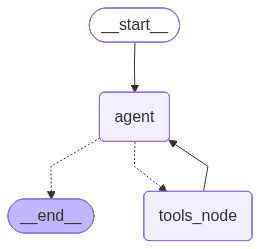

In [36]:
agent = build_agent()
agent

In [37]:
query = "what is amazon's revenue in 2023?"
result = agent.invoke({"messages":[HumanMessage(query)]})

[AGENT] called Tool page_retrieval_rerank with args {'query': 'Amazon revenue 2023', 'k': '5'}
[Agent responding withoit tool calls]

[TOOL] retrieve_docs called
[QUERY] Amazon revenue 2023
keywords: {'company_name': 'amazon', 'fiscal_year': 2023}
references: ['revenue', 'net revenue', 'consolidated statements of operations', 'operating income', 'net income']
   [1] Doc 0: score=21.4076
   [2] Doc 4: score=20.2858
   [3] Doc 14: score=19.9250
   [4] Doc 7: score=19.5749
   [5] Doc 24: score=18.1246
[RETRIEVED] 5 documents


In [38]:
result

{'messages': [HumanMessage(content="what is amazon's revenue in 2023?", additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:397b-cloud', 'created_at': '2026-03-11T15:31:45.765301182Z', 'done': True, 'done_reason': 'stop', 'total_duration': 791337076, 'load_duration': None, 'prompt_eval_count': 1238, 'prompt_eval_duration': None, 'eval_count': 104, 'eval_duration': None, 'logprobs': None, 'model_name': 'qwen3.5:397b-cloud', 'model_provider': 'ollama'}, id='lc_run--019cdd86-7d82-7170-b140-9fca8fd2fab4-0', tool_calls=[{'name': 'page_retrieval_rerank', 'args': {'query': 'Amazon revenue 2023', 'k': '5'}, 'id': 'd99db95a-c08a-436a-a011-f1311cbb5e2a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1238, 'output_tokens': 104, 'total_tokens': 1342}),
  ToolMessage(content="--- Document 1 ---\nsource_file: amazon 10-k 2023.pdf\nfile_hash: 6e5549c7b20b0fbc5f482397070a1e85cbf8643c801ff570903f

In [40]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

## Amazon Revenue in 2023

Based on the retrieved documents from Amazon's 2023 10-K filing, here is the revenue information:

### Consolidated Net Sales

| Year | Net Sales (in millions) |
|------|------------------------|
| 2023 | **$574,785** |
| 2022 | $513,983 |

Amazon's total revenue for 2023 was **$574.8 billion**, representing a **12% year-over-year growth** compared to 2022.

### Revenue Breakdown by Segment

| Segment | 2023 Net Sales (millions) | 2022 Net Sales (millions) | YoY Growth |
|---------|--------------------------|--------------------------|------------|
| North America | $352,828 | $315,880 | 12% |
| International | $131,200 | $118,007 | 11% |
| AWS | $90,757 | $80,096 | 13% |
| **Consolidated** | **$574,785** | **$513,983** | **12%** |

### Revenue Mix

| Segment | 2023 Mix |
|---------|----------|
| North America | 61% |
| International | 23% |
| AWS | 16% |

### Key Findings

- **